Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

Carga imagen desde archivo con OpenCV y convierte a RGB

(512, 512, 3)


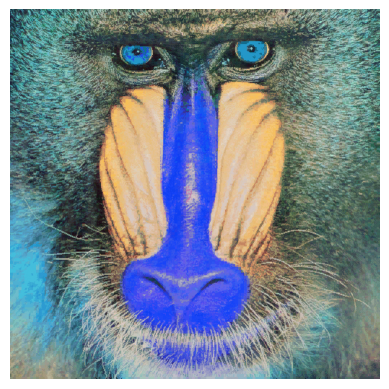

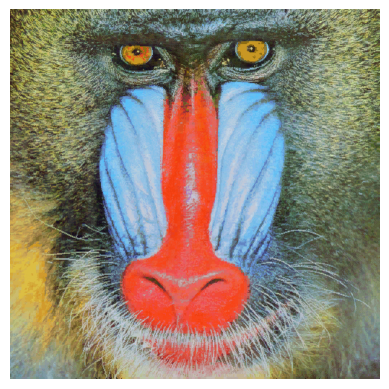

In [ ]:
#Lee imagen de archivo
img = cv2.imread('mandril.jpg') 

#Si hay lectura correcta
if img is not None:
    #Muestra dimensiones
    print(img.shape)
    #Muestra la imagen original con matplotlib
    plt.figure()
    #Elimina etiquetas de los ejes que muestra matplotlib
    plt.axis("off")
    plt.imshow(img) 
    plt.show()

    #Recordar que OpenCV lee las imágenes almacenando en formato BGR, por lo que convertimos para visualizar de forma correcta a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Muestra la imagen tras convertir a RGB
    #Eliminamos etiquetas de los ejes
    plt.figure()
    plt.axis("off")
    plt.imshow(img_rgb) 
    plt.show()
else: 
    print('Imagen no encontrada')

Escribe un texto en una posición de la imagen

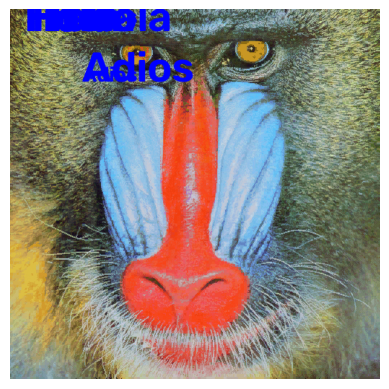

In [ ]:
# Define tipografías (Bastante limitadas en OpenCV)
font = cv2.FONT_HERSHEY_SIMPLEX
    
# Define parámetros del texto
position=(100,100)
font_scale=2.0
color=(0, 0, 255)
thickness=2
# Añade texto a la imagen
cv2.putText(img_rgb, "Adios", position, font, font_scale, color, thickness)

plt.figure()
plt.axis("off")
plt.imshow(img_rgb) 
plt.show()

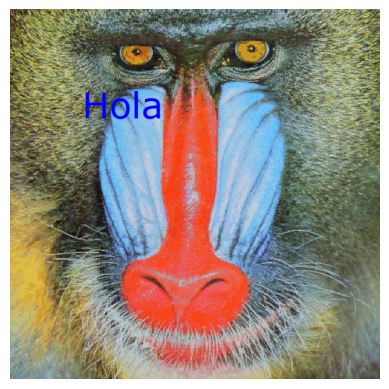

In [33]:
#Para más tipografías, usar PIL como alternativa
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Conversión de numpy array a PIL Image (tener presente que debe ser RGB, por ello la conversión previa)
pil_image = Image.fromarray(img_rgb) 
#Crea objeto para dibujar
draw = ImageDraw.Draw(pil_image)

# Carga tipografía (puede haber errores) y define parámetros
position=(100,100)
font_size=50.0
color=(0, 0, 255)
#Tipografías en Windows
#font = ImageFont.truetype("arial.ttf", font_size)
#font = ImageFont.truetype("times.ttf", font_size)
font = ImageFont.truetype("verdana.ttf", font_size)
#font = ImageFont.truetype("tahoma.ttf", font_size)

# Añade texto a la imagen
draw.text(position, "Hola", fill=color, font=font)

# Convierte resultado a numpy array para matplotlib
final_img_rgb = np.array(pil_image)

plt.figure()
plt.axis("off")
plt.imshow(final_img_rgb) 
plt.show()

Convierte la imagen a grises para procesamiento posterior

(512, 512)


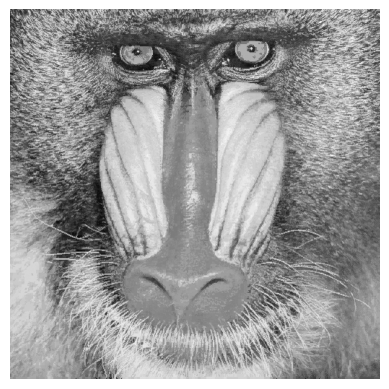

In [ ]:
#Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gris.shape)
#Muestra, indicando el mapa de color de grises con matplotlib
plt.figure()
#Eliminamos etiquetas de los ejes
plt.axis("off")
#Muestra la imagen en grises
plt.imshow(gris, cmap='gray') 
plt.show()


Canny, detector de contornos multietapa. Descrito en mayor detalle en las sesiones de teoría (tema 4)

[[  0 255   0 ...   0   0   0]
 [  0 255   0 ... 255   0   0]
 [255   0   0 ...   0 255 255]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


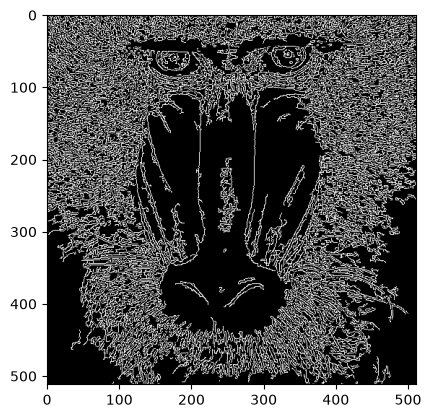

In [12]:
#Obtiene contornos con el operador de Canny
#Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 64, 224) #prueba a jugar con umbrales (entre 0 y 255)
print(canny) #Muestra contenido, valores 0 o 255
#Visualiza resultado
plt.imshow(canny, cmap='gray') 
plt.show()


Cuenta el número de píxeles no nulos por columna y visualiza el vector resultante

[[  0 255   0 ...   0   0   0]
 [  0 255   0 ... 255   0   0]
 [255   0   0 ...   0 255 255]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]
[[22440 25245 24480 26520 25500 23460 24225 26010 27030 24225 25245 21420
  24990 26775 20145 23970 24990 23715 26010 26520 24480 25500 26265 28050
  31110 25500 29325 31110 25755 25755 24990 28560 31365 29835 24990 32385
  30090 29835 26265 29580 29325 26520 28305 28560 29070 25500 31110 32385
  29325 31365 28815 33150 32385 34680 33915 35445 38760 34935 37485 39525
  39270 39780 36210 40035 42840 34170 33405 45135 41310 37230 40545 39525
  41310 37485 33150 37740 39015 36210 35190 39525 40290 36210 36465 41055
  42330 41820 43350 38505 41310 39015 41565 40035 45390 36720 41820 34680
  43095 40545 38250 45390 44625 37740 42075 44115 47685 43350 38760 42330
  40800 41310 40290 39015 45135 39270 39015 46920 40290 37740 40290 47175
  36465 37485 36210 43350 41055 40800 37230 41055 34170 39015 40290 

(0.0, 512.0)

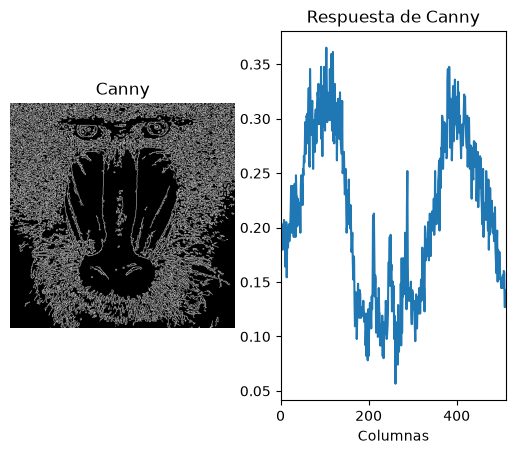

In [ ]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
print(canny)
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
print(col_counts)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
cols = col_counts[0] / (255 * canny.shape[0])

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)
#Rango en x definido por las columnas
plt.xlim([0, canny.shape[1]])

## TAREA 1
- Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Fila @ 90%:   6 	Valor:  [0.390625]
Fila @ 90%:   15 	Valor:  [0.40429688]
Fila @ 90%:   20 	Valor:  [0.39453125]
Fila @ 90%:   21 	Valor:  [0.40039062]
Fila @ 90%:   88 	Valor:  [0.39453125]
Fila @ 90%:   98 	Valor:  [0.39257812]
Fila @ 90%:   100 	Valor:  [0.4140625]
512


(0.0, 512.0)

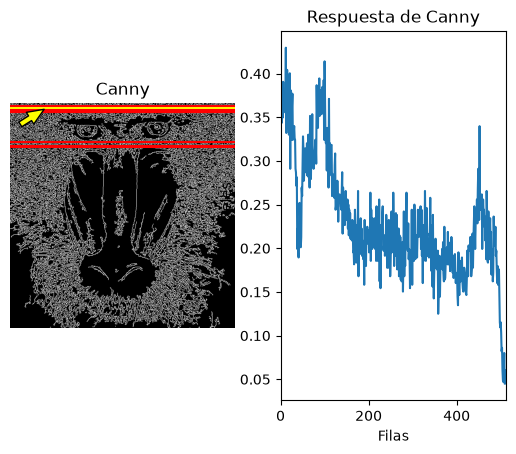

In [17]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
#print(canny)
#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de COLUMNAS, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por FILA

rows = row_counts / (255 * canny.shape[1])
fila_max = np.argmax(rows)

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

# Flechita para indicar fila con máximo de pixels blancos
plt.annotate(
    '',                      # Texto vacío (solo queremos la flecha)
    xy=(80, 12),             # Coordenadas de la PUNTA de la flecha
    xytext=(20, 50),         # Coordenadas de la COLA de la flecha
    arrowprops=dict(
        facecolor='yellow',  # Color de relleno de la flecha
        edgecolor='black',   # Color del borde
        shrink=0.05,         # Espacio libre en los extremos
        width=4,             # Grosor del cuerpo de la flecha
        headwidth=10         # Ancho de la cabeza de la flecha
    )
)

# Fila con el máximo valor de píxeles blancos
plt.axhline(y=fila_max, color='yellow', linestyle='-')

# Filas con valor del 90% del máximo anterior
for i in range(0,len(rows)):
    if (rows[i] > rows[fila_max] * 0.90) & (i != fila_max):
        print("Fila @ 90%:  ", i, "\tValor: ", rows[i])
        plt.axhline(i, color='red', linestyle='-')
        
plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
#Rango en y definido por las filas
print(canny.shape[1])
plt.xlim([0, canny.shape[0]])

Canny es el detector de bordes más destacado antes de los modelos de aprendizaje profundo. Un detector más simple es Sobel (realmente suele usarse como primer paso de Canny).
El operador de Sobel considera que cuando hay un borde, el valor de intensidad de los píxeles cercanos cambia de forma notable, calcular las derivadas proporciona una evidencia de dicho cambio. El operador de Sobel aproxima el cálculo de la derivada aplicando un kernel de tamaño impar basado en el patrón [1 2 1].

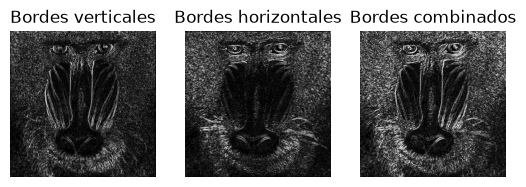

In [38]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)

#Muestra ambos resultados
plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('Bordes verticales')
#Verticales
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobelx), cmap='gray') 
#plt.imshow(sobelx, cmap='gray') #Prueba sin convertir escala

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('Bordes horizontales')
#Horizontales
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobely), cmap='gray') 
#plt.imshow(sobelx, cmap='gray') #Prueba sin convertir escala

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Bordes combinados')
#Para visualizar convierte a escala manejable en una imagen de grises
plt.imshow(cv2.convertScaleAbs(sobel), cmap='gray') 
#plt.imshow(sobel, cmap='gray') #Prueba sin convertir escala
plt.show()

Observa que visualizar la imagen resultado de Sobel directamente como escala de grises produce un resultado diferente. Ha sido necesario convertir a datos de tipo byte. La siguiente celda muestra dos variantes de conversión, con OpenCV y numpy, evidenciando alguna diferencia, además de los valores antes y tras escalar a 8 bits

Tipo de datos, valor mínimo y máximo en sobel: float64, -594.0, 570.0
Tipo de datos, valor mínimo y máximo en sobel8: uint8, 0, 255
Tipo de datos, valor mínimo y máximo en sobel8np: uint8, 0, 254


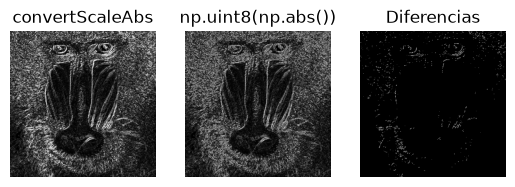

In [ ]:
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel: {sobel.dtype}, {np.min(sobel)}, {np.max(sobel)}")

# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8: {sobel8.dtype}, {np.min(sobel8)}, {np.max(sobel8)}")

# Conversión a byte con numpy
sobel8np = np.uint8(np.abs(sobel))
# Mostrar el tipo de dato de los valores en la imagen soble, además de valores máximo y mínimo
print(f"Tipo de datos, valor mínimo y máximo en sobel8np: {sobel8np.dtype}, {np.min(sobel8np)}, {np.max(sobel8np)}")

plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('convertScaleAbs')
plt.imshow(sobel8, cmap='gray') 

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('np.uint8(np.abs())')
plt.imshow(sobel8np, cmap='gray') 

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Diferencias')
plt.imshow(cv2.absdiff(sobel8,sobel8np), cmap='gray') 

plt.show()

Umbralizado de una imagen

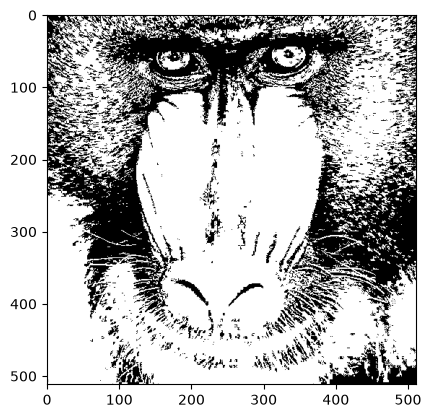

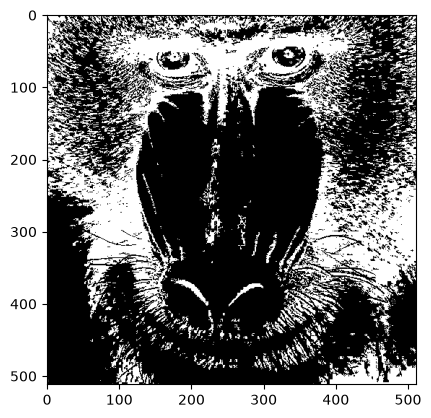

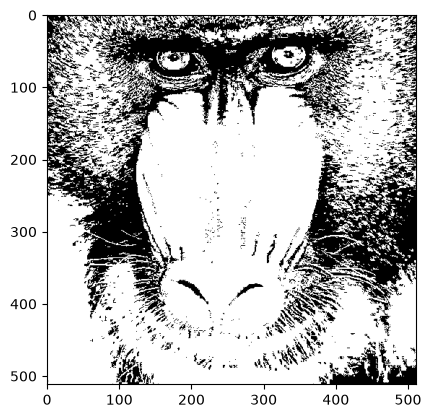

In [ ]:
#Define valor umbral
valorUmbral = 112 #Prueba otros valores
#Obtiene imagen umbralizada para dicho valor definido
_, imagenUmbralizada = cv2.threshold(gris, valorUmbral, 255, cv2.THRESH_BINARY)
#Muestra resultado
plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

#El umbralizado inverso, los valores menores que el umbral se muestran en blanco
_, imagenUmbralizada = cv2.threshold(gris, valorUmbral, 255, cv2.THRESH_BINARY_INV)
#Muestra resultado
plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

#Valores en rango determinado por dos umbrales
imagenEnRango = cv2.inRange(gris, 110, 240)
#Muestra resultado
plt.imshow(imagenEnRango, cmap='gray')
plt.show()

El histograma de una imagen aporta información sobre el valor de umbral a elegir para ciertas situaciones

(0.0, 256.0)

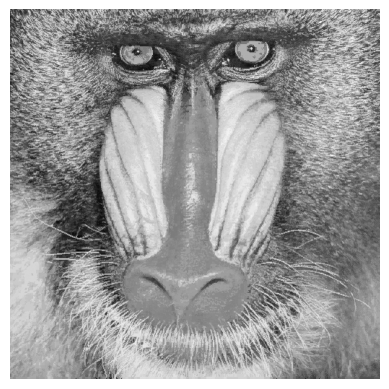

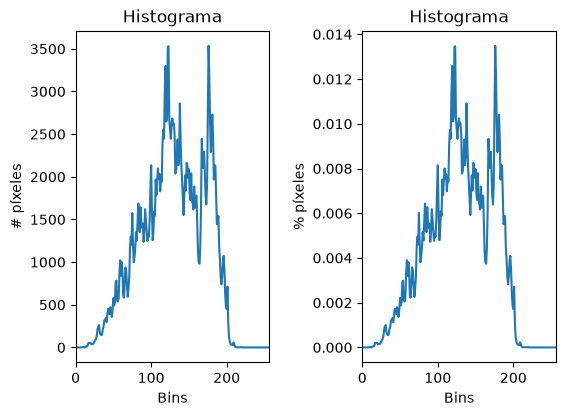

In [ ]:
#Cálculo del histograma de una imagen en escala de grises
hist = cv2.calcHist([gris], [0], None, [256], [0, 256])

plt.figure()
plt.axis("off")
plt.imshow(gris, cmap='gray')

# Histograma sin normalizar
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("# píxeles")
plt.plot(hist)
plt.xlim([0, 256])

#Normaliza el histograma en base al número de píxeles y lo muestra
hist /= hist.sum()

plt.subplot(1, 2, 2)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("% píxeles")
plt.tight_layout(pad=3.0) #separación entre plots
plt.plot(hist)
plt.xlim([0, 256])

## Tarea 2
 - Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobel tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

 Fuentes: 
 - Anotaciones en imagen: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html


Canny (100, 200)
Maximo nº de píxels por filas: 184; limite (90%): 165.60
Filas al 90% del máximo (5): [6, 8, 20, 24, 100]
Maximo nº de píxels por columnas: 138; limite(90%): 124.20
Columnas al 90% del máximo (3): [92, 104, 119]
Total píxeles no nulos: 34763 (13.26 %)

Sobel umbralizado (130)
Maximo nº de píxels por filas: 161; limite (90%): 144.90
Filas al 90% del máximo (7): [3, 4, 20, 51, 81, 82, 83]
Maximo nº de píxels por columnas: 179; limite(90%): 161.10
Columnas al 90% del máximo (1): [288]
Total píxeles no nulos: 31199 (11.90 %)


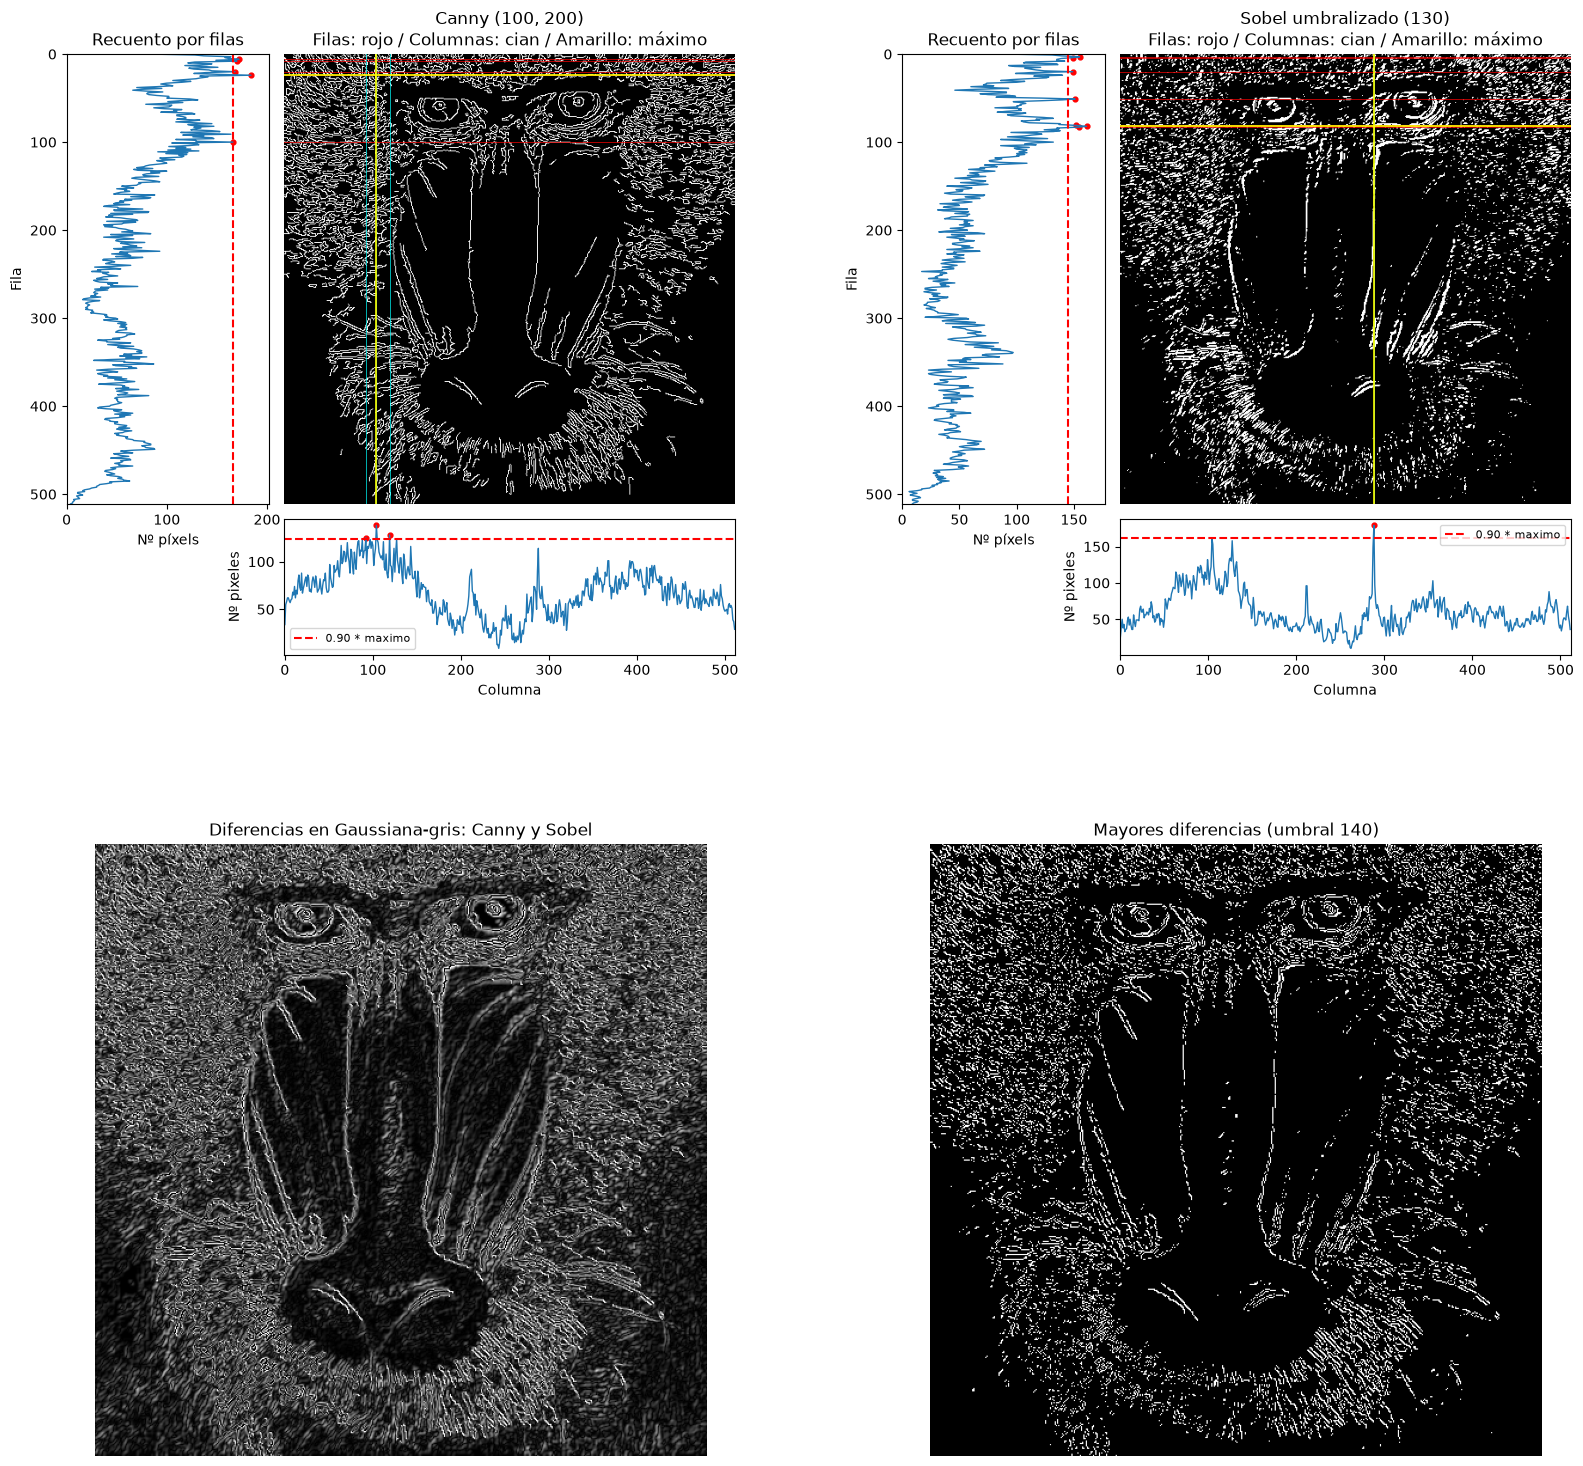

In [84]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargo imagen del mandril
mandril = cv2.imread('mandril.jpg')
if mandril is None:
    raise FileNotFoundError('No se encuentra mandril.jpg')

#Sobel 8 bits
gris = cv2.cvtColor(mandril, cv2.COLOR_BGR2GRAY)
gauss_gris = cv2.GaussianBlur(gris, (3, 3), 0)
sobelx = cv2.Sobel(gauss_gris, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(gauss_gris, cv2.CV_64F, 0, 1)
sobel8 = cv2.convertScaleAbs(cv2.add(sobelx, sobely))

valorUmbralSobel = 130
_, sobel_umbralizado = cv2.threshold(sobel8, valorUmbralSobel, 255, cv2.THRESH_BINARY)

canny = cv2.Canny(gauss_gris, 100, 200)

resultados = {}

from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
fig.subplots_adjust(left=0.04, right=0.98, bottom=0.06, top=0.94,
                    hspace=0.30, wspace=0.25)
for panel_titulo, (nombre, bordes) in enumerate([
    ('Canny (100, 200)', canny),
    (f'Sobel umbralizado ({valorUmbralSobel})', sobel_umbralizado),
]):
    # Cuenta real de pixeles no nulos, sin dividir por el ancho o el alto.
    recuento_filas = np.count_nonzero(bordes, axis=1)
    recuento_columnas = np.count_nonzero(bordes, axis=0)

    fila_max = int(recuento_filas.max())
    col_max = int(recuento_columnas.max())
    filas = np.flatnonzero(recuento_filas > 0.90 * fila_max)
    columnas = np.flatnonzero(recuento_columnas > 0.90 * col_max)

    resultados[nombre] = dict(maxfil=fila_max, maxcol=col_max,
        filas=filas, columnas=columnas, total=int(np.count_nonzero(bordes)))
    print(f'\n{nombre}')
    print(f'Maximo nº de píxels por filas: {fila_max}; limite (90%): {0.90 * fila_max:.2f}')
    print(f'Filas al 90% del máximo ({len(filas)}): {filas.tolist()}')
    print(f'Maximo nº de píxels por columnas: {col_max}; limite(90%): {0.90 * col_max:.2f}')
    print(f'Columnas al 90% del máximo ({len(columnas)}): {columnas.tolist()}')
    print(f'Total píxeles no nulos: {np.count_nonzero(bordes)} ({100 * np.count_nonzero(bordes) / bordes.size:.2f} %)')
    
    ax_imagen = axes[0, panel_titulo]
    ax_imagen.imshow(bordes, cmap='gray', vmin=0, vmax=255)
    for y in filas:
        ax_imagen.axhline(y, color='red', linewidth=0.7, alpha=0.7)
    for x in columnas:
        ax_imagen.axvline(x, color='cyan', linewidth=0.7, alpha=0.7)
    # Posiciones de la fila y columna con más píxeles blancos.
    indice_fila_max = int(np.argmax(recuento_filas))
    indice_columna_max = int(np.argmax(recuento_columnas))

    # Dibujamos los máximos al final en amarillo para destacarlos.
    ax_imagen.axhline(indice_fila_max, color='yellow', linewidth=1.2, zorder=5)
    ax_imagen.axvline(indice_columna_max, color='yellow', linewidth=1.2, zorder=5)
    ax_imagen.set_title(f'{nombre}\nFilas: rojo / Columnas: cian / Amarillo: máximo')
    ax_imagen.axis('off')

    divisor = make_axes_locatable(ax_imagen)
    ax_filas = divisor.append_axes('left', size='45%', pad=0.15, sharey=ax_imagen)
    ax_columnas = divisor.append_axes('bottom', size='30%', pad=0.15, sharex=ax_imagen)

    # Recuento de filas, con marcado de frontera del 90%
    ax_filas.plot(recuento_filas, np.arange(len(recuento_filas)), linewidth=1)
    ax_filas.axvline(0.90 * fila_max, color='red', linestyle='--')
    ax_filas.scatter(recuento_filas[filas], filas, color='red', s=12)
    ax_filas.set(xlabel='Nº píxels', ylabel='Fila', title='Recuento por filas', xlim=(0, max(1, fila_max * 1.1)))
    ax_filas.set_ylim(bordes.shape[0] - 0.5, -0.5)

    # Recuento de columnas, con marcado de frontera del 90%
    ax_columnas.plot(recuento_columnas, linewidth=1)
    ax_columnas.axhline(0.90 * col_max, color='red', linestyle='--', label='0.90 * maximo')
    ax_columnas.scatter(columnas, recuento_columnas[columnas], color='red', s=12)
    ax_columnas.set(xlabel='Columna', ylabel='Nº pixeles', xlim=(-0.5, bordes.shape[1] - 0.5))
    ax_columnas.legend(fontsize=8)

# Diferencias entre Canny y Sobel umbralizado.
diferencia_imgs = cv2.absdiff(canny, sobel8)

umbral_diferencias = 140
_, imgdif = cv2.threshold(
    diferencia_imgs, umbral_diferencias, 255, cv2.THRESH_BINARY
)

# Diferencias: fila inferior, columna izquierda.
axes[1, 0].imshow(diferencia_imgs, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Diferencias en Gaussiana-gris: Canny y Sobel')
axes[1, 0].axis('off')

# Mayores diferencias: fila inferior, columna derecha.
axes[1, 1].imshow(imgdif, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title(f'Mayores diferencias (umbral {umbral_diferencias})')
axes[1, 1].axis('off')

plt.show()


### Comparacion de resultados entre el detector de contornos "Canny" y su predecesor "Sobel"

- Se aplica el umbral 130 a **Sobel convertido a 8 bits**, y se compara con Canny (100, 200).
- Se cuentan pixeles no nulos mediante `np.count_nonzero`: `axis=1` para filas y `axis=0` para columnas.
- Realizamos el recuento de filas en las que los pixels alcanzan un valor **> 0.90 * del maximo**.
- Las líneas rojas marcan las filas y las de color cian las columnas sobre la imagen ya tratada con los detectores.
- Las líneas amarillas marcan tanto fila como columna máxima.

| Método detector | Maximo por fila | Maximo por columna | Filas seleccionadas | Columnas seleccionadas | Pixeles no nulos |
|---|---:|---:|---:|---:|---:|
| Canny | 220 | 187 | 5 | 3 | 55 509 (21.18 %) |
| Sobel (umbralizado) | 161 | 179 | 7 | 1 | 31199 (11.90 %) |

En la imagen de ejemplo (mandril), ambos detectores seleccionan similar número de filas, no así de columnas, pero cabe destacar que:
* Canny presenta contornos mas finos y continuos, y conserva más detalle del pelo. 
* Sobel-umbralizado produce trazos más gruesos y fragmentados, descartando muchos de ellos debido al umbral elegido.

Diferencia de imágenes

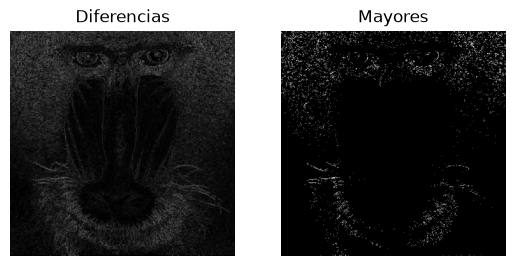

In [81]:
#Calcula la diferencia entre dos imágenes
#Utiliza la imagen original y la obtenida tras aplicar la gaussiana (creada en la celda dedicada a Sobel)
dif = cv2.absdiff(gris, ggris)

#Visualiza
plt.figure()
plt.subplot(1, 2, 1)
plt.title("Diferencias")
plt.axis("off")
plt.imshow(dif, cmap='gray') 

#Zonas de mayor diferencia tras aplicar umbral
res, imgdif = cv2.threshold(dif, 30, 255, cv2.THRESH_BINARY)
#Visualiza
plt.subplot(1, 2, 2)
plt.title("Mayores")
plt.axis("off")
plt.imshow(imgdif, cmap='gray') 
plt.show()


Webcam y sustracción de fotogramas

In [ ]:
vid = cv2.VideoCapture(0)

#Marca de inicio
disponible = 0 
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        if disponible > 0:
            dif = cv2.absdiff(frame, pframe)        
            # Muestra resultado
            cv2.imshow('Diferencia', dif)    
        else:
            disponible = 1

        #Copia fotograma actual para la diferencia en el siguiente forograma
        pframe = frame.copy()
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Webcam y sustracción de modelo del fondo

In [6]:
vid = cv2.VideoCapture(0)

# Fondo
# Inicializa la sustracción del fondo con mezcla de gaussianas y detección de sombras
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        # Aplica efecto espejo sobre la entrada
        framem=cv2.flip(frame, 1)
        
        #Con un segundo parámerto se puede definir máscara con zonas a actualizar
        objetos = eliminadorFondo.apply(framem)
        #objetos = eliminadorFondo.apply(framem, objetos, 0)  #No actualiza el fondo
        # Obtiene fondo
        background = eliminadorFondo.getBackgroundImage()

        # Muestra resultado
        cv2.imshow('Fotograma', objetos)
        # Muestra fondo
        cv2.imshow('Fondo', background)
  
   
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

## TAREA 3
- Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [11]:
import cv2
import numpy as np
import time

# Parámetros del efecto.
CAMARA = 0
SEGUNDOS_REEMPANADO = 5.0
UMBRAL_MOVIMIENTO = 50
AREA_MINIMA = 80
RADIO_LIMPIEZA = 14
INTENSIDAD_VAHO = 0.45


def actualizar_espejo(frame, gris_anterior, claridad, dt):
    # Reducimos la imagen para detectar movimiento con menos ruido y coste.
    alto, ancho = frame.shape[:2]
    ancho_detector = min(320, ancho)
    alto_detector = max(1, round(alto * ancho_detector / ancho))

    pequena = cv2.resize(frame, (ancho_detector, alto_detector))
    gris_actual = cv2.GaussianBlur(
        cv2.cvtColor(pequena, cv2.COLOR_BGR2GRAY),
        (5, 5),
        0
    )

    # Claridad: 0 = empañado; 1 = completamente nítido.
    if claridad is None or claridad.shape != (alto, ancho):
        claridad = np.zeros((alto, ancho), dtype=np.float32)
        gris_anterior = None

    # La zona limpia se vuelve a empañar según el tiempo transcurrido.
    claridad = np.maximum(
        claridad - dt / SEGUNDOS_REEMPANADO, 0.0
    )

    if gris_anterior is not None and gris_anterior.shape == gris_actual.shape:
        # Diferencia entre fotogramas para detectar movimiento.
        diferencia = cv2.absdiff(gris_actual, gris_anterior)
        _, movimiento = cv2.threshold(
            diferencia, UMBRAL_MOVIMIENTO, 255, cv2.THRESH_BINARY
        )

        # Eliminamos ruido y unimos pequeñas zonas de movimiento.
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        movimiento = cv2.morphologyEx(
            movimiento, cv2.MORPH_OPEN, kernel
        )
        movimiento = cv2.morphologyEx(
            movimiento, cv2.MORPH_CLOSE, kernel, iterations=2
        )

        contornos, _ = cv2.findContours(
            movimiento, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )

        pasada = np.zeros_like(movimiento)
        for contorno in contornos:
            if cv2.contourArea(contorno) >= AREA_MINIMA:
                cv2.drawContours(
                    pasada, [contorno], -1, 255, cv2.FILLED
                )

        # Ensanchamos la huella y suavizamos sus bordes.
        diametro = 2 * RADIO_LIMPIEZA + 1
        pincel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (diametro, diametro)
        )
        pasada = cv2.dilate(pasada, pincel)
        pasada = cv2.GaussianBlur(
            pasada.astype(np.float32) / 255.0, (15, 15), 0
        )
        pasada = cv2.resize(pasada, (ancho, alto))

        # El movimiento limpia, manteniendo las huellas anteriores.
        claridad = np.maximum(claridad, pasada)

    # Creamos el vaho: desenfoque y una capa blanquecina.
    borrosa = cv2.GaussianBlur(frame, (0, 0), sigmaX=14)
    vaho = cv2.addWeighted(
        borrosa, 1.0 - INTENSIDAD_VAHO,
        np.full_like(frame, 255), INTENSIDAD_VAHO,
        0
    )

    # Mezclamos la imagen nítida y la empañada.
    alfa = claridad[:, :, np.newaxis]
    resultado = (
        frame * alfa + vaho * (1.0 - alfa)
    ).astype(np.uint8)

    return resultado, gris_actual, claridad


ventana = 'Espejo empanado - Tarea 3'
vid = cv2.VideoCapture(CAMARA)

gris_anterior = None
claridad = None
ventana_abierta = False

try:
    if not vid.isOpened():
        raise RuntimeError(
            'No se puede abrir la webcam. '
            'Comprueba permisos y otras aplicaciones.'
        )

    vid.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    vid.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

    cv2.namedWindow(ventana, cv2.WINDOW_AUTOSIZE)
    ventana_abierta = True
    instante_anterior = time.monotonic()

    print('Mueve la mano para limpiar.')
    print('ESC o Q: salir. R: volver a empañar todo.')

    while True:
        ret, frame = vid.read()
        if not ret:
            print('No se ha podido leer un fotograma de la webcam.')
            break

        instante = time.monotonic()
        dt = instante - instante_anterior
        instante_anterior = instante

        # Invertimos horizontalmente para simular un espejo.
        frame = cv2.flip(frame, 1)

        resultado, gris_anterior, claridad = actualizar_espejo(
            frame, gris_anterior, claridad, dt
        )

        cv2.putText(
            resultado,
            'Mueve la mano | R: empanar | ESC/Q: salir',
            (12, 25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (40, 40, 40),
            1,
            cv2.LINE_AA
        )
        cv2.imshow(ventana, resultado)

        tecla = cv2.waitKey(1) & 0xFF

        if tecla in (27, ord('q'), ord('Q')):
            break

        if tecla in (ord('r'), ord('R')):
            claridad.fill(0.0)

        if cv2.getWindowProperty(ventana, cv2.WND_PROP_VISIBLE) < 1:
            break

except KeyboardInterrupt:
    print('Captura detenida.')

finally:
    vid.release()
    if ventana_abierta:
        try:
            cv2.destroyWindow(ventana)
        except cv2.error:
            pass  # La ventana puede haberse cerrado manualmente.

Mueve la mano para limpiar.
ESC o Q: salir. R: volver a empañar todo.


---


In [ ]:
import cv2
import numpy as np

# Parámetros de la simulación
RADIO = 22
GRAVEDAD = 900.0
REBOTE = 0.82
UMBRAL_GOLPE = 0.20
IMPULSO_VERTICAL = 650.0
ESPERA_ENTRE_GOLPES = 0.20


def histograma_normalizado(zona, bins=32):
    """Calcula el histograma normalizado de una zona en escala de grises."""
    histograma = cv2.calcHist([zona], [0], None, [bins], [0, 256])
    return cv2.normalize(histograma, None, alpha=1.0, norm_type=cv2.NORM_L1)


def variacion_histograma(actual, anterior):
    """Compara dos histogramas: devuelve un valor próximo a 0 si son similares y próximo a 1 si son muy diferentes."""
    if actual.size == 0 or anterior.size == 0:
        return 0.0

    histograma_actual = histograma_normalizado(actual)
    histograma_anterior = histograma_normalizado(anterior)

    return cv2.compareHist(histograma_actual, histograma_anterior, cv2.HISTCMP_BHATTACHARYYA)


def medir_movimiento_local(gris, gris_anterior, x, y, radio):
    """Mide la variación del histograma en la zona que rodea la pelota."""
    alto, ancho = gris.shape
    alcance = int(2.2 * radio)

    x0 = max(0, x - alcance)
    x1 = min(ancho, x + alcance + 1)
    y0 = max(0, y - alcance)
    y1 = min(alto, y + alcance + 1)

    zona_actual = gris[y0:y1, x0:x1]
    zona_anterior = gris_anterior[y0:y1, x0:x1]

    return variacion_histograma(zona_actual, zona_anterior)


def dibujar_histograma(frame, variacion, umbral):
    """Genera una imagen con los histogramas B, G y R."""
    alto = frame.shape[0]
    ancho = 420
    margen_superior = 65
    margen_inferior = 45

    lienzo = np.full((alto, ancho, 3), 25, dtype=np.uint8)

    cv2.putText(lienzo, "Histograma RGB en tiempo real", (14, 27), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (235, 235, 235), 1, cv2.LINE_AA)

    # Colores BGR correspondientes a los canales B, G y R.
    colores = ((255, 80, 80), (80, 255, 80), (80, 80, 255))

    altura_grafica = max(80, alto - margen_superior - margen_inferior)

    for canal, color in enumerate(colores):
        histograma = cv2.calcHist([frame], [canal], None, [256], [0, 256]).ravel()
        histograma = cv2.normalize(histograma, None, 0, altura_grafica, cv2.NORM_MINMAX).ravel()
        puntos = np.column_stack((np.linspace(8, ancho - 9, 256), alto - margen_inferior - histograma)).astype(np.int32)

        cv2.polylines(lienzo, [puntos], False, color, 1, cv2.LINE_AA)

    if variacion >= umbral:
        color_estado = (80, 220, 80)
    else:
        color_estado = (210, 210, 210)

    cv2.putText(lienzo, f"Variacion junto a la pelota: {variacion:.3f}", (14, alto - 17), cv2.FONT_HERSHEY_SIMPLEX, 0.48, color_estado, 1, cv2.LINE_AA)

    return lienzo


# Abre la webcam
vid = cv2.VideoCapture(0)

gris_anterior = None
posicion = None

# La pelota tiene movimiento horizontal inicial, pero los golpes no modifican su velocidad horizontal.
velocidad = np.array([140.0, 0.0], dtype=np.float64)

ultimo_instante = cv2.getTickCount() / cv2.getTickFrequency()
ultimo_golpe = -np.inf

ventana_webcam = "Webcam - pelota"
ventana_histograma = "Histograma en tiempo real"

cv2.namedWindow(ventana_webcam, cv2.WINDOW_AUTOSIZE)
cv2.namedWindow(ventana_histograma, cv2.WINDOW_AUTOSIZE)

ventanas_colocadas = False

print("Mueve la mano junto a la pelota. R: reiniciar; ESC/Q: salir.")

while True:
    ret, frame = vid.read()

    if not ret:
        print("No se ha podido leer la webcam.")
        break

    # Comportamiento de espejo
    frame = cv2.flip(frame, 1)

    alto, ancho = frame.shape[:2]
    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Tiempo transcurrido desde el fotograma anterior
    ahora = cv2.getTickCount() / cv2.getTickFrequency()
    dt = float(np.clip(ahora - ultimo_instante, 0.001, 0.05))
    ultimo_instante = ahora

    # Posición inicial de la pelota
    if posicion is None:
        posicion = np.array([ancho / 2.0, RADIO + 15.0], dtype=np.float64)

    variacion = 0.0

    # Detección del golpe mediante variación del histograma
    if gris_anterior is not None and gris_anterior.shape == gris.shape:
        variacion = medir_movimiento_local(gris, gris_anterior, int(posicion[0]), int(posicion[1]), RADIO)
        tiempo_desde_golpe = ahora - ultimo_golpe

        if variacion >= UMBRAL_GOLPE and tiempo_desde_golpe >= ESPERA_ENTRE_GOLPES:
            # El golpe solo modifica la velocidad vertical.
            velocidad[1] = -max(IMPULSO_VERTICAL, abs(velocidad[1]) * 0.9)
            ultimo_golpe = ahora

    # Aplica la gravedad
    velocidad[1] += GRAVEDAD * dt

    # Actualiza la posición
    posicion += velocidad * dt

    # Rebote con el borde izquierdo
    if posicion[0] - RADIO < 0:
        posicion[0] = RADIO
        velocidad[0] = abs(velocidad[0]) * REBOTE

    # Rebote con el borde derecho
    elif posicion[0] + RADIO >= ancho:
        posicion[0] = ancho - RADIO - 1
        velocidad[0] = -abs(velocidad[0]) * REBOTE

    # Rebote con el borde superior
    if posicion[1] - RADIO < 0:
        posicion[1] = RADIO
        velocidad[1] = abs(velocidad[1]) * REBOTE

    # Rebote con el borde inferior
    elif posicion[1] + RADIO >= alto:
        posicion[1] = alto - RADIO - 1
        velocidad[1] = -abs(velocidad[1]) * REBOTE

        # Evita rebotes mínimos continuos
        if abs(velocidad[1]) < 70.0:
            velocidad[1] = 0.0

    centro = tuple(np.rint(posicion).astype(int))

    # Indica visualmente que se ha detectado un golpe
    golpe_detectado = ahora - ultimo_golpe < 0.12

    if golpe_detectado:
        cv2.circle(frame, centro, RADIO + 8, (0, 255, 0), 2, cv2.LINE_AA)

    # Dibuja la pelota con borde
    cv2.circle(frame, centro, RADIO, (0, 255, 0), -1, cv2.LINE_AA)
    cv2.circle(frame, centro, RADIO, (0, 0, 0), 2, cv2.LINE_AA)

    cv2.putText(frame, "Golpea debajo de la pelota | R: reiniciar | ESC: salir", (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (255, 255, 255), 1, cv2.LINE_AA)

    # Genera y muestra la ventana del histograma
    panel_histograma = dibujar_histograma(frame, variacion, UMBRAL_GOLPE)

    cv2.imshow(ventana_webcam, frame)
    cv2.imshow(ventana_histograma, panel_histograma)

    # Coloca ambas ventanas una al lado de la otra
    if not ventanas_colocadas:
        cv2.moveWindow(ventana_webcam, 30, 50)
        cv2.moveWindow(ventana_histograma, 30 + ancho + 15, 50)
        ventanas_colocadas = True

    # Guarda el fotograma para la siguiente comparación
    gris_anterior = gris.copy()

    tecla = cv2.waitKey(1) & 0xFF

    if tecla == 27:
        break

    if tecla in (ord("r"), ord("R")):
        posicion[:] = (ancho / 2.0, RADIO + 15.0)
        velocidad[:] = (140.0, 0.0)
        gris_anterior = None

    if cv2.getWindowProperty(ventana_webcam, cv2.WND_PROP_VISIBLE) < 1:
        break

vid.release()
cv2.destroyAllWindows()